Exp 8: Implement Multiclass Classification models for students
Performance Level analysis and perform comparative analysis.
(Random Forest, Decision Tree, Multinomial Logistic Regression,
XGBoost, K-Nearest Neighbors).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [ ]:
# Load dataset
data = pd.read_csv("/content/drive/MyDrive/python-ml-lab/exp5_6_7_8/multiclass_classification_dataset_500_samples.csv")
data.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Internal_Marks,Participation,Internet_Access,Previous_Grade,Performance_Level
0,22.48,84.26,86.79,76.68,Medium,Yes,B,1
1,19.31,94.09,81.10,56.73,Low,Yes,B,1
2,23.24,61.01,70.72,52.73,Medium,Yes,A,0
3,27.62,80.63,62.24,64.95,Low,Yes,C,0
4,18.83,68.49,78.38,62.45,High,Yes,B,0


In [ ]:
data.shape

(500, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            500 non-null    float64
 1   Attendance_Percentage  500 non-null    float64
 2   Assignment_Score       500 non-null    float64
 3   Internal_Marks         500 non-null    float64
 4   Participation          500 non-null    object 
 5   Internet_Access        500 non-null    object 
 6   Previous_Grade         500 non-null    object 
 7   Performance_Level      500 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 31.4+ KB


In [ ]:
data['Internet_Access'].value_counts()

,count
Internet_Access,
Yes,402
No,98


In [ ]:
data['Performance_Level'].value_counts()

,count
Performance_Level,
1,249
0,247
2,4


In [ ]:
# 1. Encode Target: Performance_Level (Low, Medium, High)
le_target = LabelEncoder()
data['Performance_Level'] = le_target.fit_transform(data['Performance_Level'])

# 2. Encode Categorical Features
# Internet_Access (Yes/No) -> Numeric using LabelEncoder
le_internet = LabelEncoder()
data['Internet_Access'] = le_internet.fit_transform(data['Internet_Access'])

# Previous_Grade (A0, B1, C0...) -> Numeric
le_grade = LabelEncoder()
data['Previous_Grade'] = le_grade.fit_transform(data['Previous_Grade'])

# Participation (Low, Medium, High) -> Numeric
le_participation = LabelEncoder()
data['Participation'] = le_participation.fit_transform(data['Participation'])

# 3. Define Features and Target
X = data.drop(['Performance_Level'], axis=1)
y = data['Performance_Level']

# 4. Feature Scaling (Critical for KNN and Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
X_train

array([[ 0.40527224, -1.47429844, -1.6504945 , ...,  1.13351245,
         0.49374193,  1.26779787],
       [ 0.72608977, -2.28616613, -0.68579193, ..., -0.06979164,
         0.49374193, -1.35161922],
       [-1.45015655,  0.73783602,  0.31363001, ..., -0.06979164,
        -2.02534955, -0.04191067],
       ...,
       [-0.7410885 , -0.6860077 , -1.46284456, ...,  1.13351245,
        -2.02534955,  1.26779787],
       [ 0.06810731, -0.54659608,  0.17309922, ..., -1.27309573,
        -2.02534955,  1.26779787],
       [-0.35692483,  0.8598212 ,  1.96445352, ..., -0.06979164,
         0.49374193, -1.35161922]])

In [ ]:
y_train

,Performance_Level
249,0
433,0
19,1
322,1
332,1
...,...
106,1
270,1
348,0
435,0


In [ ]:
# --- Create All Models ---
# Modified Logistic Regression for explicit Multinomial (Softmax) classification
LR = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
LR.fit(X_train, y_train)

RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train, y_train)

XGB = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
XGB.fit(X_train, y_train)

DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train, y_train)

KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:05:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KNeighborsClassifier()

In [ ]:
# ---  Accuracy Scores ---
lr_acc = accuracy_score(y_test, LR.predict(X_test))
rf_acc = accuracy_score(y_test, RF.predict(X_test))
xgb_acc = accuracy_score(y_test, XGB.predict(X_test))
dt_acc = accuracy_score(y_test, DT.predict(X_test))
knn_acc = accuracy_score(y_test, KNN.predict(X_test))

print(f"Logistic Regression Accuracy: {lr_acc}")
print(f"Random Forest Accuracy: {rf_acc}")
print(f"XGBoost Accuracy: {xgb_acc}")
print(f"Decision Tree Accuracy: {dt_acc}")
print(f"K-Nearest Neighbors Accuracy: {knn_acc}")

Logistic Regression Accuracy: 0.97
Random Forest Accuracy: 0.94
XGBoost Accuracy: 0.95
Decision Tree Accuracy: 0.9
K-Nearest Neighbors Accuracy: 0.79


In [ ]:
# --- Precision Scores ---
lr_precision = precision_score(y_test, LR.predict(X_test), average='weighted')
rf_precision = precision_score(y_test, RF.predict(X_test), average='weighted')
xgb_precision = precision_score(y_test, XGB.predict(X_test), average='weighted')
dt_precision = precision_score(y_test, DT.predict(X_test), average='weighted')
knn_precision = precision_score(y_test, KNN.predict(X_test), average='weighted')

print(f"LR Precision:  {lr_precision:.4f}")
print(f"RF Precision:  {rf_precision:.4f}")
print(f"XGB Precision: {xgb_precision:.4f}")
print(f"DT Precision:  {dt_precision:.4f}")
print(f"KNN Precision: {knn_precision:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LR Precision:  0.9517
RF Precision:  0.9216
XGB Precision: 0.9321
DT Precision:  0.9000
KNN Precision: 0.7750


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# --- Recall Scores ---
lr_recall = recall_score(y_test, LR.predict(X_test), average='weighted')
rf_recall = recall_score(y_test, RF.predict(X_test), average='weighted')
xgb_recall = recall_score(y_test, XGB.predict(X_test), average='weighted')
dt_recall = recall_score(y_test, DT.predict(X_test), average='weighted')
knn_recall = recall_score(y_test, KNN.predict(X_test), average='weighted')

print(f"\nLR Recall:     {lr_recall:.4f}")
print(f"RF Recall:     {rf_recall:.4f}")
print(f"XGB Recall:    {xgb_recall:.4f}")
print(f"DT Recall:     {dt_recall:.4f}")
print(f"KNN Recall:    {knn_recall:.4f}")


LR Recall:     0.9700
RF Recall:     0.9400
XGB Recall:    0.9500
DT Recall:     0.9000
KNN Recall:    0.7900


In [ ]:
# --- ROC-AUC Scores ---

lr_auc = roc_auc_score(y_test, LR.predict_proba(X_test), multi_class='ovr')
rf_auc = roc_auc_score(y_test, RF.predict_proba(X_test), multi_class='ovr')
xgb_auc = roc_auc_score(y_test, XGB.predict_proba(X_test), multi_class='ovr')
dt_auc = roc_auc_score(y_test, DT.predict_proba(X_test), multi_class='ovr')
knn_auc = roc_auc_score(y_test, KNN.predict_proba(X_test), multi_class='ovr')

print(f"\nLR ROC-AUC:    {lr_auc:.4f}")
print(f"RF ROC-AUC:    {rf_auc:.4f}")
print(f"XGB ROC-AUC:   {xgb_auc:.4f}")
print(f"DT ROC-AUC:    {dt_auc:.4f}")
print(f"KNN ROC-AUC:   {knn_auc:.4f}")


LR ROC-AUC:    0.9402
RF ROC-AUC:    0.9907
XGB ROC-AUC:   0.9955
DT ROC-AUC:    0.9333
KNN ROC-AUC:   0.7680


In [ ]:
# ---  F1 Scores ---
lr_f1 = f1_score(y_test, LR.predict(X_test), average='weighted')
rf_f1 = f1_score(y_test, RF.predict(X_test), average='weighted')
xgb_f1 = f1_score(y_test, XGB.predict(X_test), average='weighted')
dt_f1 = f1_score(y_test, DT.predict(X_test), average='weighted')
knn_f1 = f1_score(y_test, KNN.predict(X_test), average='weighted')


print(f"LR F1-Score:  {lr_f1:.4f}")
print(f"RF F1-Score:  {rf_f1:.4f}")
print(f"XGB F1-Score: {xgb_f1:.4f}")
print(f"DT F1-Score:  {dt_f1:.4f}")
print(f"KNN F1-Score: {knn_f1:.4f}")


LR F1-Score:  0.9604
RF F1-Score:  0.9306
XGB F1-Score: 0.9406
DT F1-Score:  0.9000
KNN F1-Score: 0.7821


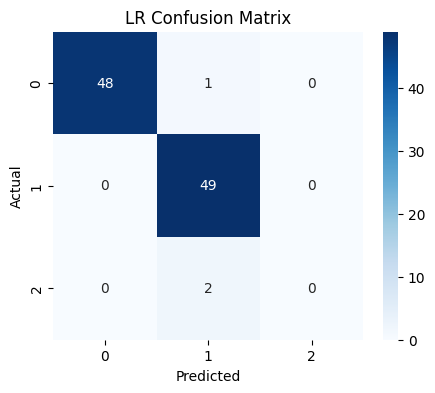

In [ ]:
# Logistic Regression Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, LR.predict(X_test)), annot=True, fmt='d', cmap='Blues',xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("LR Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

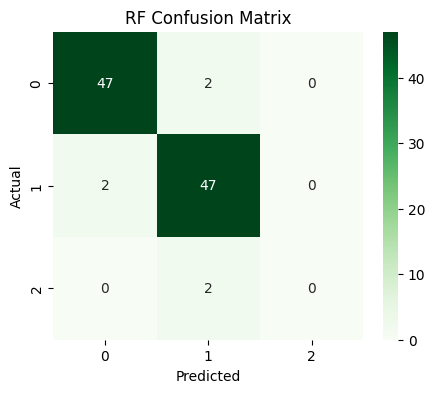

In [ ]:
# Random Forest Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, RF.predict(X_test)), annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("RF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

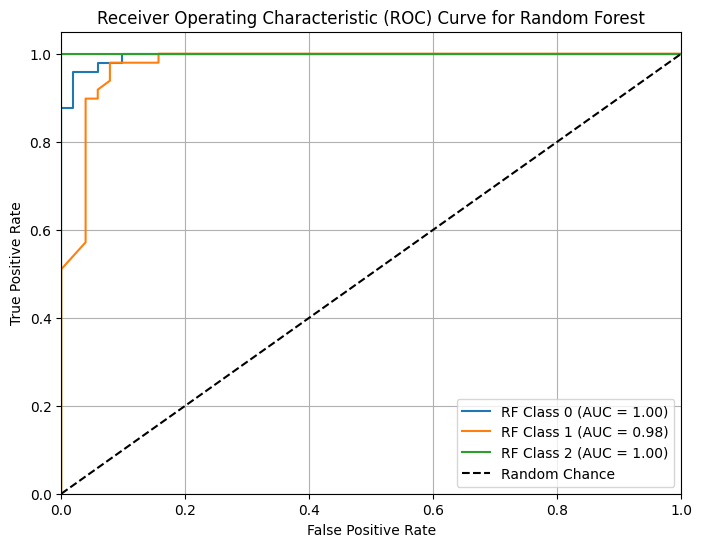

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

y_proba_rf = RF.predict_proba(X_test)

# For multiclass, plot OvR for each class
for i in range(len(le_target.classes_)): # Iterate over each class
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'RF Class {le_target.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

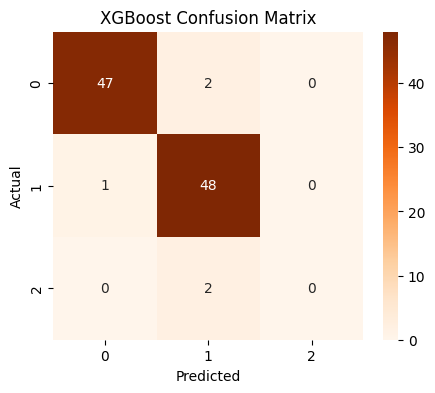

In [ ]:
# XGBoost Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, XGB.predict(X_test)), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

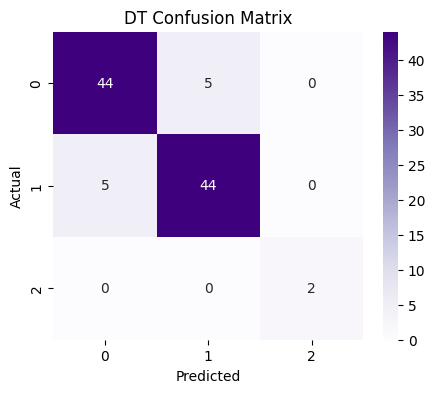

In [ ]:
# Decision Tree Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, DT.predict(X_test)), annot=True, fmt='d', cmap='Purples',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("DT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

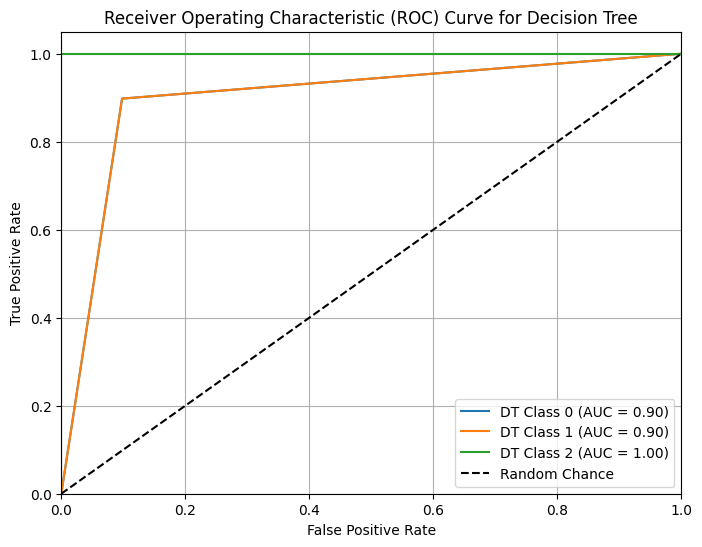

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

y_proba_dt = DT.predict_proba(X_test)

# For multiclass, plot OvR for each class
for i in range(len(le_target.classes_)): # Iterate over each class
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'DT Class {le_target.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

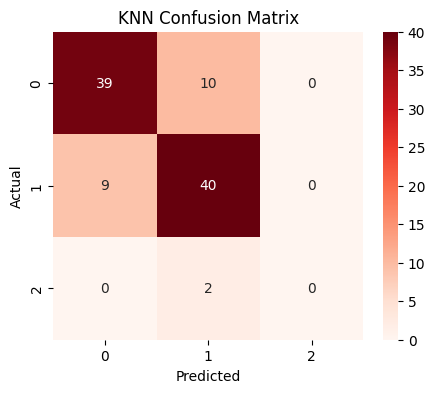

In [ ]:
# K-Nearest Neighbors Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, KNN.predict(X_test)), annot=True, fmt='d', cmap='Reds',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

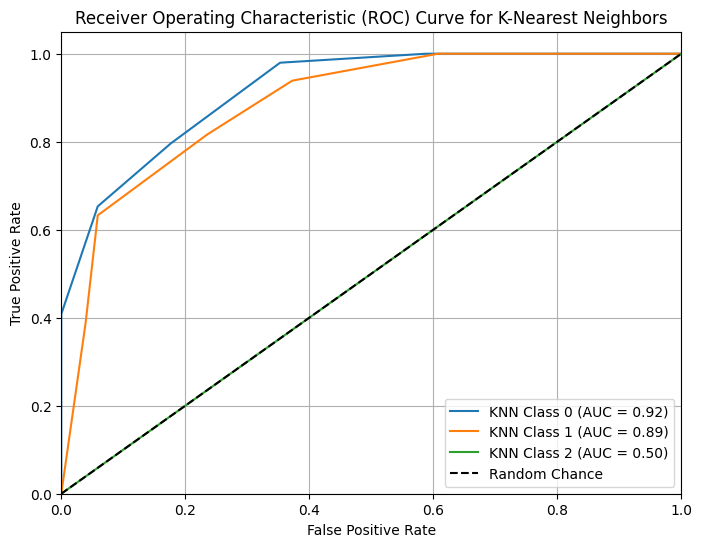

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

y_proba_knn = KNN.predict_proba(X_test)

# For multiclass, plot OvR for each class
for i in range(len(le_target.classes_)): # Iterate over each class
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba_knn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'KNN Class {le_target.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for K-Nearest Neighbors')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
#saving the model
import pickle
import os

save_dir = '/content/drive/MyDrive/python-ml-lab/exp5_6_7_8/Exp8_models'
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'LR.pkl'), 'wb') as file:
    pickle.dump(LR, file)
print('LR Model Saved to Drive')

with open(os.path.join(save_dir, 'RF.pkl'), 'wb') as file:
    pickle.dump(RF, file)
print('RF Model Saved to Drive')

with open(os.path.join(save_dir, 'XGB.pkl'), 'wb') as file:
    pickle.dump(XGB, file)
print('XGB Model Saved to Drive')

with open(os.path.join(save_dir, 'DT.pkl'), 'wb') as file:
    pickle.dump(DT, file)
print('DT Model Saved to Drive')

with open(os.path.join(save_dir, 'KNN.pkl'), 'wb') as file:
    pickle.dump(KNN, file)
print('KNN Model Saved to Drive')

with open(os.path.join(save_dir, 'scaler.pkl'), 'wb') as file:
    pickle.dump(scaler, file)
print('Scaler Saved to Drive')

LR Model Saved to Drive
RF Model Saved to Drive
XGB Model Saved to Drive
DT Model Saved to Drive
KNN Model Saved to Drive
Scaler Saved to Drive
